# Train/Set up model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define important model parameters and variables
N_AL = 50  # number of Antennal Lobe neurons
N_ODOR_ACTIVE = 20  # how many AL neurons each odor activates
N_MB = 2000  # number of Mushroom Body neurons
N_OUTPUT = 1  # single output neuron for avoidance decision
rng = np.random.default_rng(seed=123)  # for reproducibility

# Store activity history for plotting
output_history = [] 
w_mb_out_history = []

# Initialise our two odors
def make_odor(N_AL, N_ODOR_ACTIVE, seed=None):
    """
    Returns a binary vector of length n_al
    with n_active neurons set to 1.
    Each odor activates a random non-overlapping subset.
    """
    rng = np.random.default_rng(seed)
    odor = np.zeros(N_AL)
    active_indices = rng.choice(N_AL, size=N_ODOR_ACTIVE, replace=False)
    odor[active_indices] = 1
    return odor



## Define activity related functions

In [52]:
def sigmoid(x):
    return 1/ (1+np.exp(-x))


def forward(odor_pattern, w_al_mb, w_mb_out, dopamine):
    """
    One forward pass through the network.
    Returns output neuron activity.

    odor_pattern: binary vector of length n_al
    dopamine: float, 1.0 if shock present, 0.0 if not
    """
    # AL -> MB
    mb_input = odor_pattern @ w_al_mb
    mb_activity = sigmoid(mb_input)

    # # Apply inhibition: suppresses weakly activated MB neurons
    # # Simple approximation of paper's inhibitory neuron
    # inhibition_threshold = np.percentile(mb_activity, 70)
    # mb_activity[mb_activity < inhibition_threshold] = 0.0

    # MB -> Output
    out_input = np.dot(w_mb_out, mb_activity)
    out_activity = sigmoid(out_input)

    return mb_activity, out_activity


def avoidance(out_activity, threshold=0.7):
    """
    Does the fly avoid the odor?
    Threshold is a hyperparameter students can adjust.
    """
    return out_activity > threshold

## Define weight update functions

# Test model (experimental trials)

### Initialise inputs, weights, and variables to track results

In [53]:
# Make two distinct odors
odor1 = make_odor(seed=42)
odor2 = make_odor(seed=99)
assert np.array_equal(odor1, odor2) == False # Verify they are non-overlapping

# Initialise weight matrices (0-1 random weights)
# AL -> MB: sparse random connections
w_al_mb = rng.random((N_AL, N_MB))

# MB -> Output: single output neuron
w_mb_out = rng.random(N_MB) 

print("Odor shape:", odor1.shape)
print("AL->MB weights shape:", w_al_mb.shape)
print("MB->Output weights shape:", w_mb_out.shape)
# print("AL->MB weights sample:", w_al_mb[:5, :5])  
# print("MB->Output weights sample:", w_mb_out[:5])

# Set experimental paradigm
N_TRIALS_PHASE1 = 10   # odor1 + shock
N_TRIALS_PHASE2 = 10   # odor1 + odor2
N_TRIALS_PHASE3 = 5    # odor2 alone (test)




Odor shape: (50,)
AL->MB weights shape: (50, 2000)
MB->Output weights shape: (2000,)


### Start trials

In [54]:
output_history = {"phase1": [], "phase2": [], "phase3": []}
print("Phase 1: odor1 + shock")
mb_activity, out_activity = forward(w_al_mb, w_mb_out, odor1, dopamine=1.0)

Phase 1: odor1 + shock


Phase 1: odor1 + shock
  Trial 1: output=1.000, avoidance=True
  Trial 2: output=1.000, avoidance=True
  Trial 3: output=1.000, avoidance=True
  Trial 4: output=1.000, avoidance=True
  Trial 5: output=1.000, avoidance=True
  Trial 6: output=1.000, avoidance=True
  Trial 7: output=1.000, avoidance=True
  Trial 8: output=1.000, avoidance=True
  Trial 9: output=1.000, avoidance=True
  Trial 10: output=1.000, avoidance=True


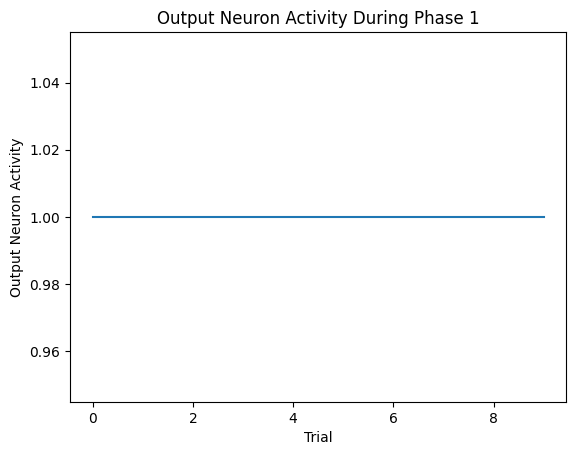

In [55]:

# --- Phase 1: First order conditioning ---
output_history = {"phase1": [], "phase2": [], "phase3": []}

# Pair odor1 with shock
print("Phase 1: odor1 + shock")

for trial in range(N_TRIALS_PHASE1):
    mb_activity, out_activity = forward(w_al_mb, w_mb_out, odor1, dopamine=1.0)
    output_history["phase1"].append(out_activity)

    print(f"  Trial {trial + 1}: output={out_activity:.3f}, "
              f"avoidance={avoidance(out_activity)}")


plt.plot(output_history["phase1"], label="Phase 1: Odor1 + Shock")
plt.xlabel("Trial")
plt.ylabel("Output Neuron Activity")
plt.title("Output Neuron Activity During Phase 1")
plt.show()


In [56]:
output_history["phase1"].append(1)
output_history["phase1"]

[np.float64(0.9999999979388463),
 np.float64(0.9999999979388463),
 np.float64(0.9999999979388463),
 np.float64(0.9999999979388463),
 np.float64(0.9999999979388463),
 np.float64(0.9999999979388463),
 np.float64(0.9999999979388463),
 np.float64(0.9999999979388463),
 np.float64(0.9999999979388463),
 np.float64(0.9999999979388463),
 1]